In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# TOP_STOCKS = ["NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "ASML"]
STOCKS = ['AAPL', 'TSLA', 'MSFT']
OUTPUT_PATH = Path("/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs")

nasdaq_stocks_list_df = pd.read_csv(OUTPUT_PATH / 'nasdaq_stocks_list.csv')
tickers_dict = dict(zip(nasdaq_stocks_list_df['Symbol'].str.strip(), nasdaq_stocks_list_df['Security Name'].str.strip()))

model_arima = joblib.load(OUTPUT_PATH / 'models/model_arima.joblib')
model_auto_arima = joblib.load(OUTPUT_PATH / 'models/model_auto_arima.joblib')
model_prophet = joblib.load(OUTPUT_PATH / 'models/model_prophet.joblib')
model_prophet_tuned = joblib.load(OUTPUT_PATH / 'models/model_prophet_tuned.joblib')
model_lstm = joblib.load(OUTPUT_PATH / 'models/model_lstm.joblib')

# EVALUATION

In [4]:
results = []
def evaluate(model, stock, model_name):
    results.append({
        'Stock': stock,
        'Model': model_name,
        'MAE': model['metrics']['mae'],
        'RMSE': model['metrics']['rmse']
    })

for stock in STOCKS:
    evaluate(model_arima[stock], stock, 'ARIMA')
    evaluate(model_auto_arima[stock], stock, 'ARIMA (Auto Arima)')
    evaluate(model_prophet[stock], stock, 'PROPHET')
    evaluate(model_prophet_tuned[stock], stock, 'PROPHET (Tuned)')
    evaluate(model_lstm[stock], stock, 'LSTM')

results_df = pd.DataFrame(results)
results_df

,Stock,Model,MAE,RMSE
0,AAPL,ARIMA,2.1307,2.9646
1,AAPL,ARIMA (Auto Arima),2.1153,2.9560
2,AAPL,PROPHET,28.4060,33.9633
3,AAPL,PROPHET (Tuned),24.7750,29.8922
4,AAPL,LSTM,7.3970,8.7721
5,TSLA,ARIMA,7.0074,10.2031
6,TSLA,ARIMA (Auto Arima),6.9281,10.0963
7,TSLA,PROPHET,56.8173,82.0118
8,TSLA,PROPHET (Tuned),60.6669,73.6390
9,TSLA,LSTM,9.6630,13.9846


In [5]:
pivot_df = results_df.pivot(index='Stock', columns='Model', values=['MAE', 'RMSE'])
pivot_df = pivot_df.sort_index(axis=1, level=1)
pivot_df

,MAE,RMSE,MAE,RMSE,MAE,RMSE,MAE,RMSE,MAE,RMSE
Model,ARIMA,ARIMA,ARIMA (Auto Arima),ARIMA (Auto Arima),LSTM,LSTM,PROPHET,PROPHET,PROPHET (Tuned),PROPHET (Tuned)
Stock,,,,,,,,,,
AAPL,2.1307,2.9646,2.1153,2.9560,7.3970,8.7721,28.4060,33.9633,24.7750,29.8922
MSFT,3.8414,5.2586,3.8207,5.2529,15.3394,17.2368,94.8415,98.0576,84.8011,88.2391
TSLA,7.0074,10.2031,6.9281,10.0963,9.6630,13.9846,56.8173,82.0118,60.6669,73.6390


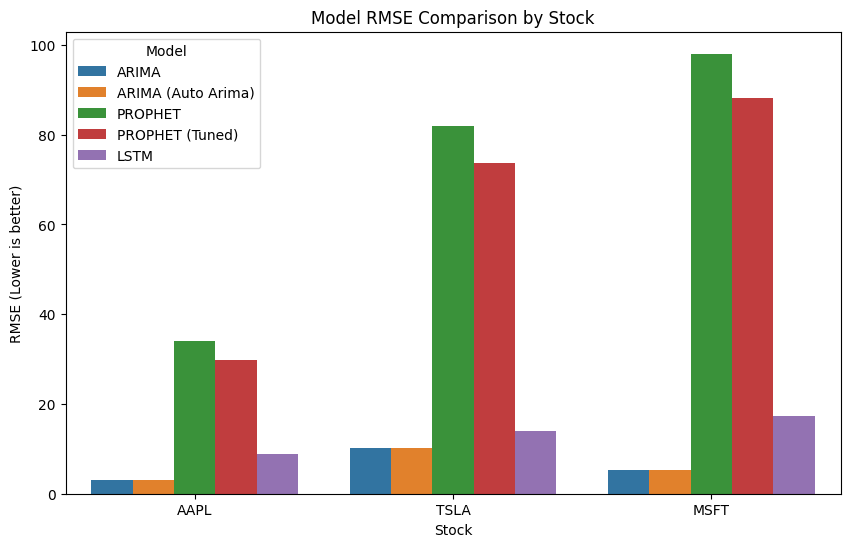

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Stock', y='RMSE', hue='Model')
plt.title("Model RMSE Comparison by Stock")
plt.ylabel("RMSE (Lower is better)")
plt.show()

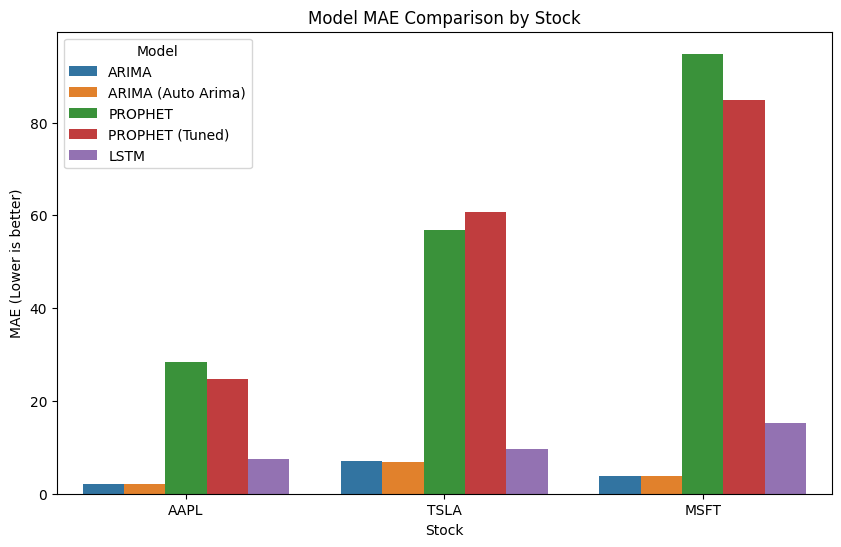

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Stock', y='MAE', hue='Model')
plt.title("Model MAE Comparison by Stock")
plt.ylabel("MAE (Lower is better)")
plt.show()

In [8]:
def plots(model, stock, model_name):
    fig, axes = plt.subplots(2, len(STOCKS), figsize=(18, 2 * len(STOCKS)))
    fig.suptitle(f'{model_name} – Residual Analysis Across Stocks', fontsize=16, fontweight='bold', y=1.02)

    for i, stock in enumerate(STOCKS):
        y_test = model[stock]['y_test']
        y_pred = model[stock]['y_pred']

        # Calculate residuals/errors
        residuals = np.array(y_test) - np.array(y_pred)
        errors = np.array(residuals)
        errors = errors[np.isfinite(errors)]

        # Residuals vs Predicted
        ax = axes[0, i]
        ax.scatter(y_pred, residuals, alpha=0.6)
        ax.axhline(0, color='red', linestyle='--')
        ax.set_title(f'{stock} - Residuals vs Predicted for {model_name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residuals')

        # Error Distribution
        ax = axes[1, i]
        sns.histplot(errors, kde=True, ax=ax, bins=30, color='skyblue', edgecolor='black')
        ax.axvline(0, color='red', linestyle='--', label='Zero Error')
        ax.set_title(f'{stock} - Error Distribution for {model_name}')
        ax.set_xlabel('Prediction Error')
        ax.legend()
    plt.tight_layout()
    plt.show()

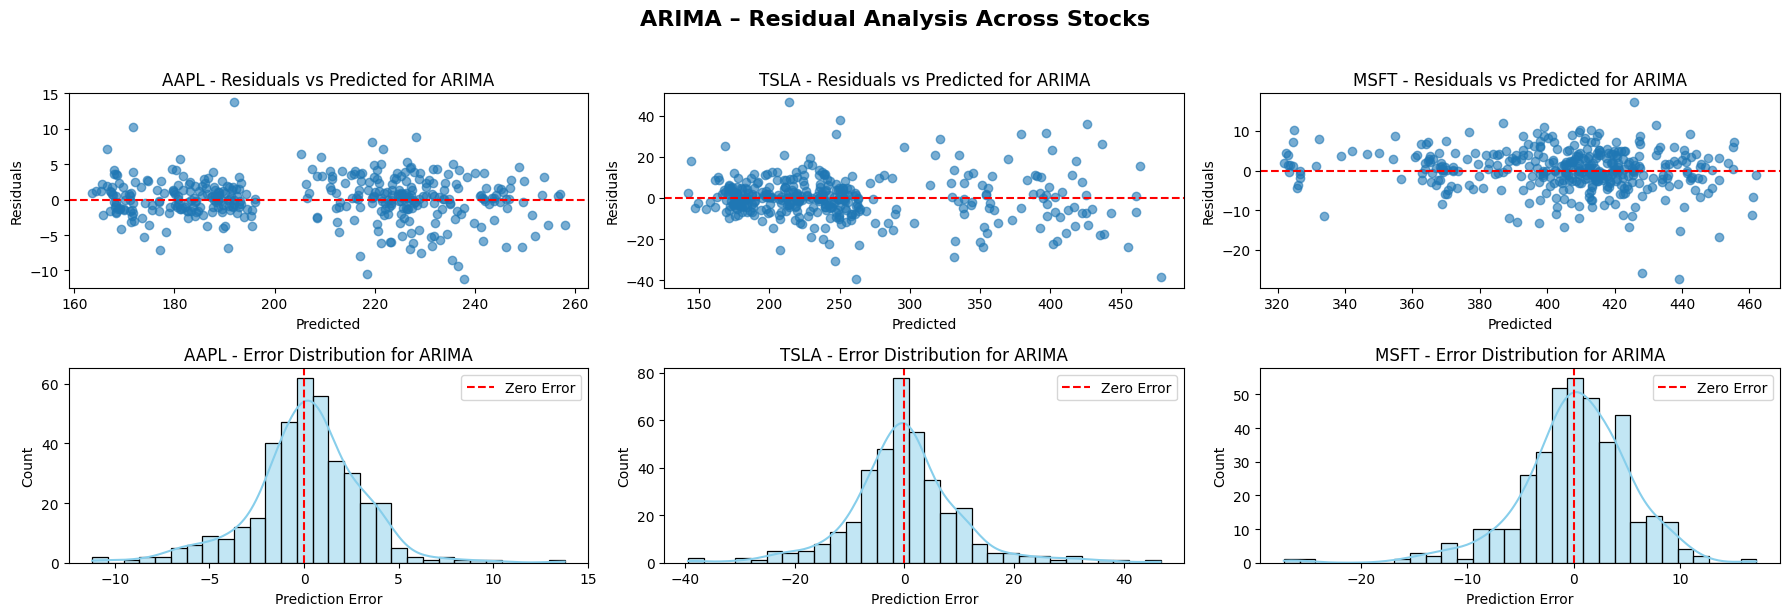

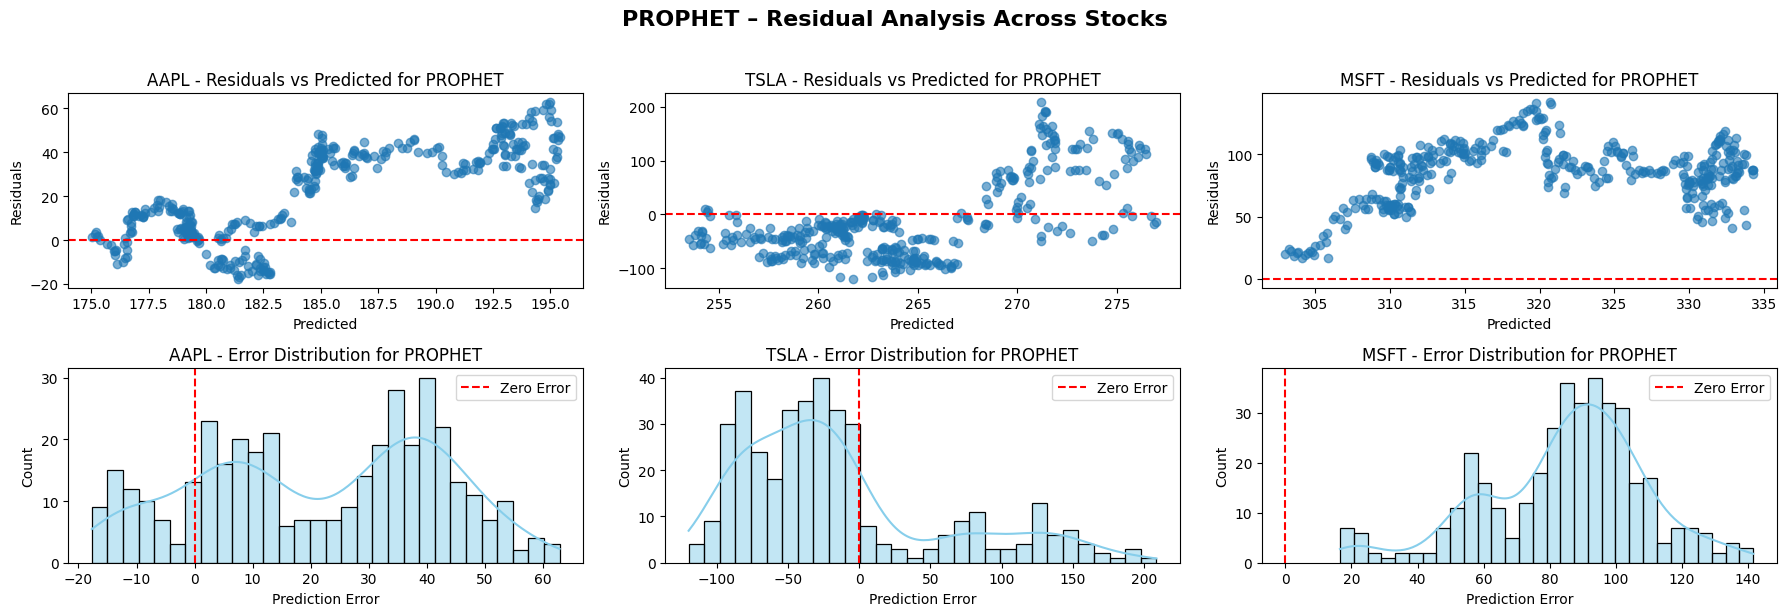

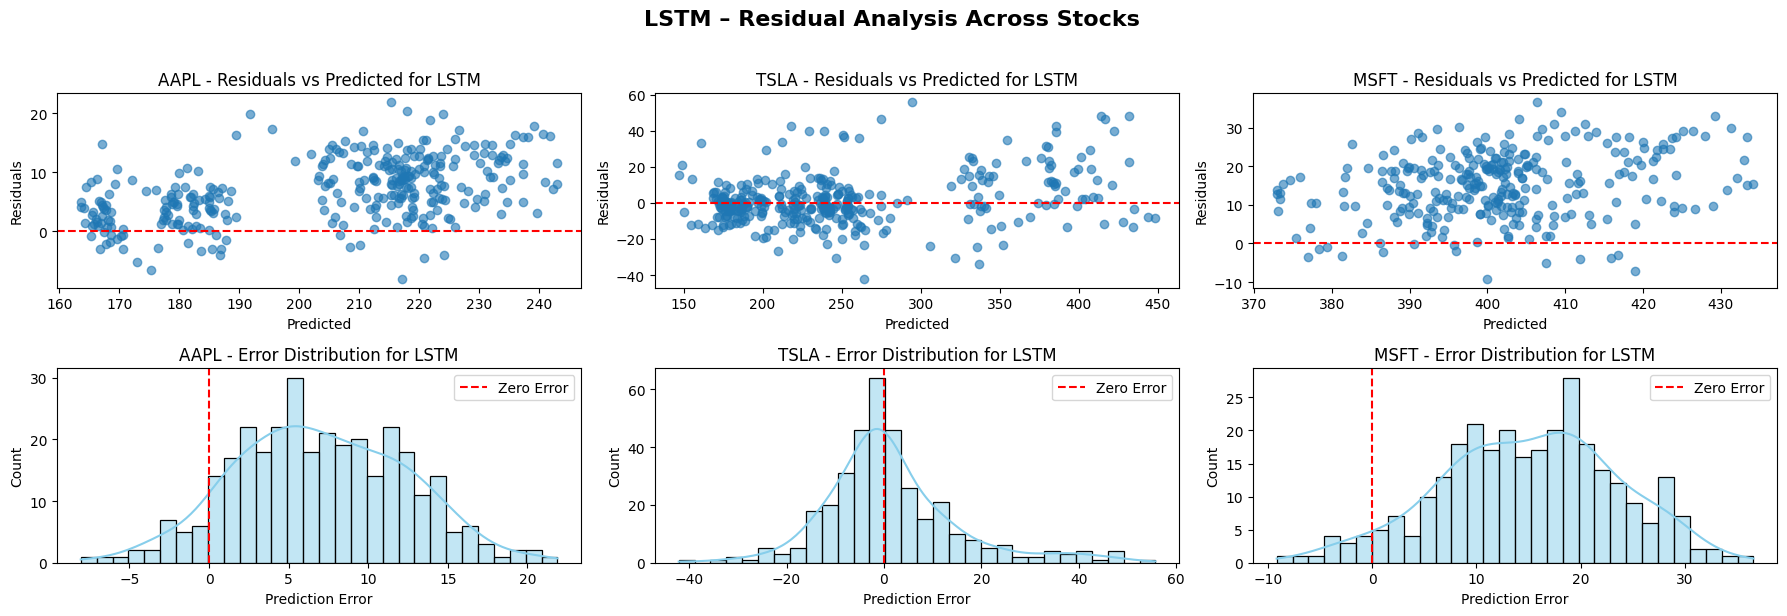

In [9]:
plots(model_arima, STOCKS, 'ARIMA')
plots(model_prophet_tuned, STOCKS, 'PROPHET')
plots(model_lstm, STOCKS, 'LSTM')